In [22]:
import strawberryfields as sf
from strawberryfields.ops import *
import numpy as np
from scipy.special import erfc
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from helper_functions import protocols
from scipy.optimize import curve_fit

In [24]:
from importlib import reload
reload(protocols)

<module 'helper_functions.protocols' from 'c:\\Users\\kmits\\Desktop\\github\\Quantum-Communications-Internship-IRIDA-\\helper_functions\\protocols.py'>

## Theoretical results (Helstrom Bound) CS vs DSS 

In [ ]:
N_helstrom = np.arange(0, 2, 0.02)
b_helstrom = np.arange(0, 1, 0.01)

# Theoretical surface
N_mesh, beta_mesh = np.meshgrid(N_helstrom, b_helstrom, indexing="ij")
p_err_theory = protocols.helstrom_bound(N_mesh, beta_mesh)

z_theory = p_err_theory
z_theory_cs = protocols.helstrom_bound(N_mesh, 0 * beta_mesh)

# Figure
fig = go.Figure()

# Theory surface
fig.add_trace(go.Surface(x=N_mesh, y=beta_mesh, z=z_theory, colorscale="Reds_r", opacity=1, showscale=False, name="Theory"))

fig.add_trace(go.Surface(x=N_mesh, y=beta_mesh, z=z_theory_cs, colorscale="Blues_r", opacity=1, showscale=False, name="Theory"))

# Layout
fig.update_layout(title="Helstrom Error probability", width=800, height=800, 
                scene=dict(xaxis_title="N", yaxis_title="β", zaxis=dict(title="P_err",type="log"),aspectmode="cube"))

fig.show()

# Coherent States Noise-Free

## Produce Data

In [ ]:
num_samples=5000
alpha_grid = np.linspace(0, np.sqrt(2), 50)
N_cs, p_err_cs = protocols.perr_cs(alpha_grid=alpha_grid, homodyne_angle=0, num_samples=num_samples)

np.savez(f"data/perr_data_cs_a{len(alpha_grid)}_S{num_samples}.npz", N_cs=N_cs, alpha_grid=alpha_grid, p_err_cs=p_err_cs)

## Load Data

In [2]:
data = np.load("data/perr_data_cs_a100_S3000.npz")

N_cs = data["N_cs"]
alpha_grid_cs = data["alpha_grid"]
p_err_cs = data["p_err_cs"]
beta_cs = 1 - N_cs/np.max(N_cs)

# DSS Noise-Free

## Produce Data

In [ ]:
N_grid = np.linspace(0, 2, 50)
beta_grid = np.linspace(0, 1, 50)
num_samples=10000
p_err = protocols.perr_dss(N_grid=N_grid, beta_grid=beta_grid, homodyne_angle=0, num_samples=num_samples)
np.savez(f"data/perr_data_dss_N{len(N_grid)}_b{len(beta_grid)}_S{num_samples}.npz", N_grid=N_grid, beta_grid=beta_grid, p_err=p_err)

## Load data

In [3]:
data = np.load("data/perr_data_dss_N50_b50_S10000.npz")

N_grid_dss = data["N_grid"]
beta_grid_dss = data["beta_grid"]
p_err_dss = data["p_err"]

## DSS/ CS Fit 

In [ ]:
params = protocols.plot_perr(N_grid_dss, beta_grid_dss, p_err_dss, p_err_cs, N_cs, dss = True, cs = True, data = False)
A_fit_cs, B_fit_cs, A_fit_dss, B_fit_dss = params 

--- CS ---
A_cs = 0.499 ± 0.002, 0.423σ away from theoretical value
B_cs = 1.410 ± 0.007, 0.577σ away from theoretical value
--- DSS ---
A_dss = 0.4995 ± 0.0002, 2.535σ away from theoretical value
B_dss = 1.413 ± 0.001, 1.674σ away from theoretical value


## Squeezing Investigation


--- THRESHOLD ---
A_th = 4.037 ± 0.022, 1.627σ away from theoretical value
B_th = 4.040 ± 0.029, 1.381σ away from theoretical value
--- OPTIMAL ---
A_opt = 0.995 ± 0.006, 0.824σ away from theoretical value
B_opt = 1.986 ± 0.016, 0.848σ away from theoretical value


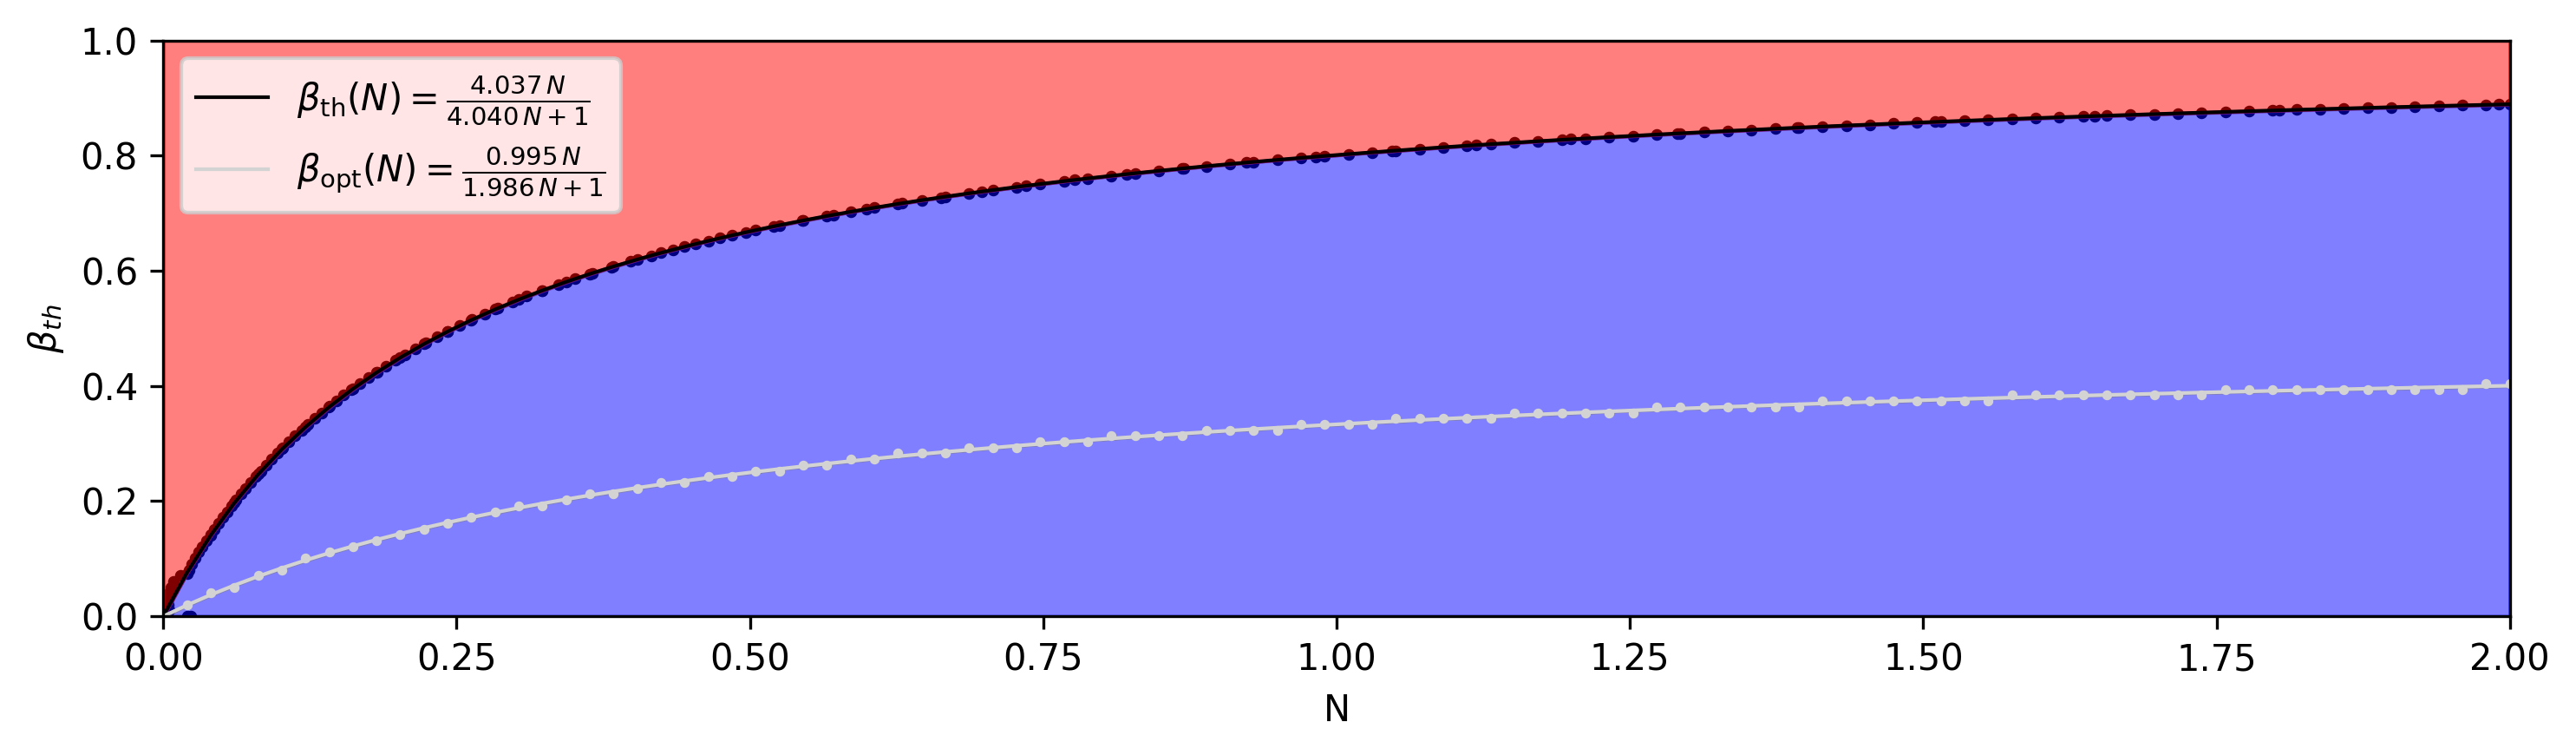

In [25]:
protocols.plot_squeezing(*params)